In [4]:
import pandas as pd
from datetime import datetime

data = pd.read_excel("data.xlsx")

data = data.drop_duplicates()

columns = []

for single_data in data :
    if single_data == "":
        single_data = pd.isna()
    if data[single_data][0] == pd.StringDtype:
        columns.append(single_data)

for col in columns:
    data[col] = data[col].str.strip()

numerical_vars = ["Quantity", "UnitPrice"]

for col in numerical_vars:
    data[col] = data[col].astype(float)
    data[col] = data[col].fillna(0)
    data = data[data[col] >= 0]

data["Description"] = data[col].fillna("No description")
data = data.drop(columns=["StockCode"])
data["CustomerID"] = data["CustomerID"].dropna()

print(data.head())

  InvoiceNo  Description  Quantity         InvoiceDate  UnitPrice  CustomerID  \
0    536365         2.55       6.0 2010-12-01 08:26:00       2.55     17850.0   
1    536365         3.39       6.0 2010-12-01 08:26:00       3.39     17850.0   
2    536365         2.75       8.0 2010-12-01 08:26:00       2.75     17850.0   
3    536365         3.39       6.0 2010-12-01 08:26:00       3.39     17850.0   
4    536365         3.39       6.0 2010-12-01 08:26:00       3.39     17850.0   

          Country  
0  United Kingdom  
1  United Kingdom  
2  United Kingdom  
3  United Kingdom  
4  United Kingdom  


In [5]:
data["Montant"] = data["Quantity"] * data["UnitPrice"]
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"], errors='coerce')

rfm = []

for customer_id, client_df in data.groupby("CustomerID"):
    rfm.append({
        "CustomerID": customer_id,
        "Recence": (pd.Timestamp.now() - client_df["InvoiceDate"].max()).days,
        "Frequence": client_df["InvoiceNo"].nunique(),
        "Montant": client_df["Montant"].sum()
    })

rfm = pd.DataFrame(rfm)
print(rfm)


      CustomerID  Recence  Frequence   Montant
0        12346.0     5733          1  77183.60
1        12347.0     5410          7   4310.00
2        12348.0     5483          4   1797.24
3        12349.0     5426          1   1757.55
4        12350.0     5718          1    334.40
...          ...      ...        ...       ...
4334     18280.0     5685          1    180.60
4335     18281.0     5588          1     80.82
4336     18282.0     5415          2    178.05
4337     18283.0     5411         16   2045.53
4338     18287.0     5450          3   1837.28

[4339 rows x 4 columns]


In [6]:
import numpy as np
from sklearn.cluster import KMeans

encoded_data = pd.get_dummies(data=data, columns=["Country"], dtype=int)
featured_data = encoded_data.select_dtypes(include=[np.number])
featured_data = featured_data.dropna()

kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    random_state=42,
    n_init=10
)

kmeans.fit(featured_data)

print(kmeans.cluster_centers_)

[[ 3.47556707e+00  1.47742542e+01  3.47556707e+00  1.32714761e+04
   2.50324528e+01  9.61633135e-03  3.26561423e-03  1.39486035e-04
   1.66644787e-02  2.62561948e-04  1.19262239e-16 -1.01915004e-17
   4.94765171e-03  2.05126522e-04  3.11792313e-03  1.27670747e-02
  -4.43709739e-17  5.62046670e-03  6.65020184e-02  7.35747809e-02
   7.46660540e-04  0.00000000e+00  1.49332108e-03  2.01023992e-03
   5.99789950e-03  2.63382454e-03  3.69227740e-04 -8.28059409e-18
   1.29562160e-17  2.32203223e-03  8.79582527e-03  2.70767009e-03
   1.19219535e-02  4.75893531e-04  7.38455479e-05  1.82152352e-03
   1.86172831e-02  2.06767534e-03  1.51137221e-02  1.46870590e-03
   3.11792313e-04  7.23103810e-01  1.26357938e-03]
 [ 3.07622503e+00  1.22322005e+01  3.07622503e+00  1.51439077e+04
   2.10703810e+01 -2.86663054e-16 -6.46184495e-17 -5.25838054e-18
   1.05818132e-16  3.83536519e-18  7.29112743e-05  5.44647219e-03
  -1.23815888e-16  7.02020907e-18 -5.54027310e-17  4.13552748e-02
   4.37467646e-04 -5.8351

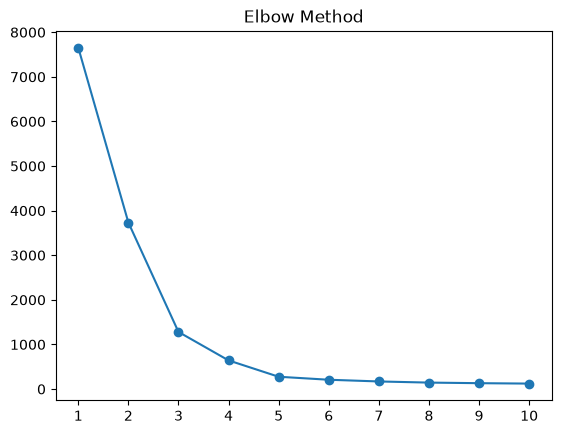

In [18]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

x , y = make_blobs(n_samples=100, centers=8, cluster_std=1, random_state=42)
inertia = []
k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    kmeans.fit(x)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker="o")
plt.title("Elbow Method")
plt.xticks(k_range)
plt.show()

In [9]:
kmeans_final = KMeans(
    n_clusters=3,
    init="k-means++",
    random_state=42,
    n_init=10
)

kmeans_final.fit(featured_data)

rfm["Cluster"] = kmeans_final.fit_predict(rfm)
print(rfm)

      CustomerID  Recence  Frequence   Montant  Cluster
0        12346.0     5733          1  77183.60        2
1        12347.0     5410          7   4310.00        0
2        12348.0     5483          4   1797.24        0
3        12349.0     5426          1   1757.55        0
4        12350.0     5718          1    334.40        0
...          ...      ...        ...       ...      ...
4334     18280.0     5685          1    180.60        0
4335     18281.0     5588          1     80.82        0
4336     18282.0     5415          2    178.05        0
4337     18283.0     5411         16   2045.53        0
4338     18287.0     5450          3   1837.28        0

[4339 rows x 5 columns]


In [10]:
variable = rfm.groupby("Cluster").agg(
    nombre_clients = ("CustomerID", "count"),
    ca_total = ("Montant" , "sum"),
    ca_avg = ("Montant" , "mean"),
    recense_avg = ("Recence" , "mean"),
    Frequence_avg = ("Frequence" , "mean"),
)

print(variable)

         nombre_clients     ca_total         ca_avg  recense_avg  \
Cluster                                                            
0                  4304  6241457.244    1450.152705  5500.621050   
1                     5  1046437.780  209287.556000  5410.200000   
2                    30  1599313.870   53310.462333  5439.833333   

         Frequence_avg  
Cluster                 
0             3.909851  
1            76.600000  
2            44.166667  


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaled = scaler.fit_transform(featured_data)
pca = PCA(n_components=2)
print(pca.fit_transform(scaled))

[[ 1.0738146   0.27430293]
 [ 1.05890199  0.32487976]
 [ 1.06712233  0.29559498]
 ...
 [-4.12560019 -1.23056934]
 [-4.12560019 -1.23056934]
 [-4.13682798 -1.1912115 ]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

x = rfm
y = rfm["Cluster"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

model_jdid = RandomForestClassifier(n_estimators=100, random_state=42)

model_jdid.fit(x_train, y_train)

model_predict = model_jdid.predict(x_test)

r2_score_res = r2_score(y_test, model_predict)

print(r2_score_res)

ValueError: Found input variables with inconsistent numbers of samples: [3471, 868]

1073.4309735672211
7705004.546776118
2775.788995362601
0.9850528234590269


Scores for each fold: [0.98503368 0.98547687 0.98582626 0.98558446 0.98600483]
Average R² Score: 0.9856


Dummy (Baseline) -> Score R² sur le test: -0.0000
Linear Regression -> Score R² sur le test: 0.9099
Ridge Regression -> Score R² sur le test: 0.9099
Random Forest Regressor -> Score R² sur le test: 0.9849
